## For understanding Ensembeled Learning Clearly 
## Visit my Markdown file here 👇: 
# [Click Here to Read](https://github.com/BhavyaKansal20/MachineLearning/blob/e6dd476b20a8c6d98578017f188527c14d9bd7b1/Ensemble%20Learning/ENSEMBLE_LEARNING.md)

In [1]:
import pandas as pd
import matplotlib.pylab as plt 
import seaborn as sns

In [2]:
dataset = pd.read_csv("/Users/bhavyakansal/Datasets/placement.csv")
dataset.head(10)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48
8,6.09,2.31
9,8.31,3.51


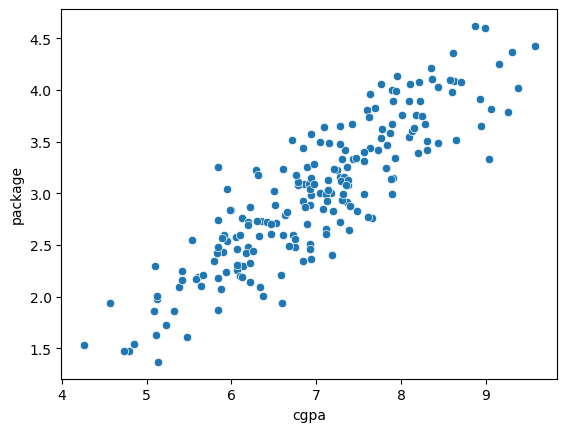

In [9]:
sns.scatterplot(x = "cgpa" , y="package" , data=dataset)
plt.show()

In [10]:
x = dataset.iloc[:,:-1]
y = dataset["package"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train , x_test , y_train , y_test = train_test_split( x , y , train_size=0.2 , random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [14]:
lr = LinearRegression()
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
lr.score(x_train ,y_train)*100 , lr.score(x_test , y_test)*100

(81.27792435566859, 76.48053777272594)

In [17]:
dt = DecisionTreeRegressor()
dt.fit(x_train , y_train)
dt.score(x_train ,y_train)*100 , dt.score(x_test , y_test)*100

(98.8783183032024, 61.204300871572606)

In [19]:
sv = SVR()
sv.fit(x_train , y_train)
sv.score(x_train ,y_train)*100 , sv.score(x_test , y_test)*100

(81.1371514641032, 76.13387346110623)

In [20]:
from sklearn.ensemble import VotingRegressor

In [24]:
models = [("lr", LinearRegression()) , ("dt" , DecisionTreeRegressor()) , ("sv", SVR())]

In [45]:
vr = VotingRegressor(models , weights=[90,5,80])
vr.fit(x_train ,y_train)
vr.score(x_train ,y_train)*100 , vr.score(x_test , y_test)*100

(82.61246947583525, 76.78351296333628)

In [46]:
prediction = {"lr" : lr.predict(x_test) , "dt" : dt.predict(x_test) , "svm" : sv.predict(x_test) , "vr":vr.predict(x_test)}

In [48]:
pd.DataFrame(prediction)

,lr,dt,svm,vr
0,2.777350,3.24,2.872321,2.833984
1,3.126812,2.94,3.128686,3.122331
2,3.188813,3.08,3.181644,3.182427
3,2.394069,2.43,2.493045,2.440341
4,3.510092,4.00,3.535779,3.535832
...,...,...,...,...
155,3.301542,3.34,3.291151,3.297891
156,3.555184,3.55,3.592850,3.572255
157,2.630801,2.59,2.750048,2.684148
158,2.072789,1.37,2.049261,2.041954
